<a href="https://colab.research.google.com/github/quasarx-snips/devjams_lunap/blob/main/integrated_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-08-26 235733.png to Screenshot 2026-08-26 235733 (1).png


/tmp/ipykernel_1508/2720727624.py:134: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('RdYlGn_r')


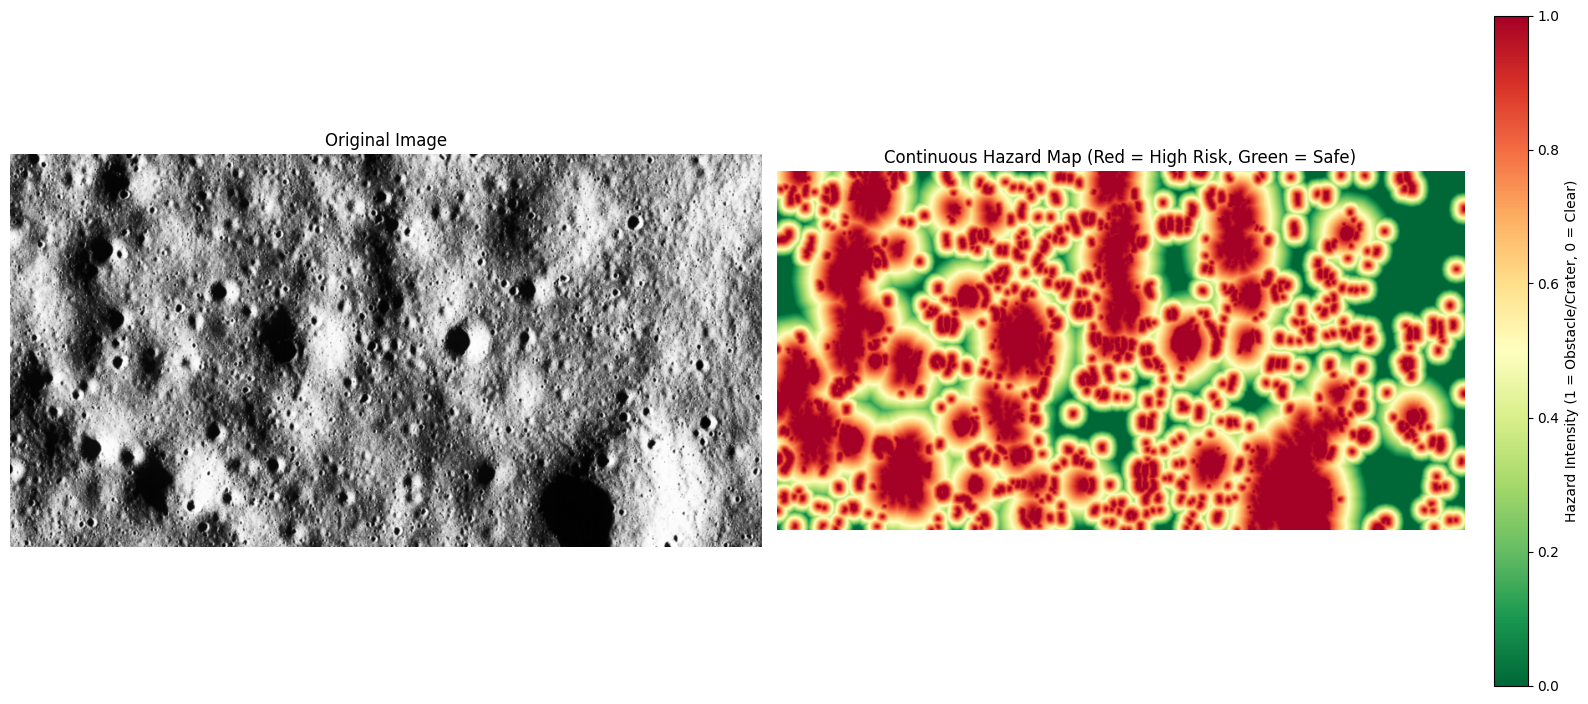

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import files

# ---------- 1. upload ----------
uploaded = files.upload()
IMAGE_PATH = next(iter(uploaded.keys()))

# ---------- 2. tunable parameters ----------
MAX_DIM               = 900
CRATER_SCALES         = [0.012, 0.022, 0.035, 0.05]
CRATER_PERCENTILE     = 96
CRATER_MIN_AREA_FRAC  = 0.008 ** 2
CRATER_CIRCULARITY    = 0.35
DARK_SHADOW_THRESH    = 45
DARK_MIN_AREA_FRAC    = 0.02 ** 2
DARK_CIRCULARITY      = 0.05
STEEP_PERCENTILE      = 93
MIN_STEEP_AREA        = 20
BOULDER_MIN_AREA      = 2
BOULDER_MAX_AREA      = 35
ALPHA                 = 1

# --- NEW: Danger Buffer Zones (fractions of image diagonal) ---
CRATER_DANGER_RADIUS  = 0.05  # How far risk radiates from craters
HAZARD_DANGER_RADIUS  = 0.02  # How far risk radiates from boulders/steep slopes

# ---------- 3. load ----------
raw = cv2.imread(IMAGE_PATH)
h, w = raw.shape[:2]
scale = MAX_DIM / max(h, w)
if scale < 1:
    raw = cv2.resize(raw, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
gray_u8 = cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
H, W = gray_u8.shape
diag = float(np.sqrt(H**2 + W**2))
den = cv2.medianBlur(gray_u8, 3)

# ---------- 4. craters: multi-scale black-hat + circularity ----------
crater_radii = [max(3, int(diag*f)) for f in CRATER_SCALES]
blackhat_stack = np.zeros((H, W), dtype=np.float32)
for r in crater_radii:
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    bh = cv2.morphologyEx(den, cv2.MORPH_BLACKHAT, k).astype(np.float32)
    blackhat_stack = np.maximum(blackhat_stack, bh)

thr = np.percentile(blackhat_stack, CRATER_PERCENTILE)
crater_bin = (blackhat_stack > thr).astype(np.uint8)
crater_bin = cv2.morphologyEx(crater_bin, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))

n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(crater_bin, connectivity=8)
crater_mask = np.zeros((H, W), dtype=bool)
min_area = CRATER_MIN_AREA_FRAC * diag**2
for i in range(1, n_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area < min_area: continue
    comp = (labels == i).astype(np.uint8)
    cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: continue
    c = max(cnts, key=cv2.contourArea)
    perim = cv2.arcLength(c, True)
    if perim == 0: continue
    circularity = 4*np.pi*area/(perim**2)
    if circularity > CRATER_CIRCULARITY:
        crater_mask |= (labels == i)

# ---------- 5. add large saturated shadow craters ----------
_, dark_bin = cv2.threshold(den, DARK_SHADOW_THRESH, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(dark_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
dark_min_area = DARK_MIN_AREA_FRAC * diag**2
for c in contours:
    area = cv2.contourArea(c)
    if area < dark_min_area: continue
    perim = cv2.arcLength(c, True)
    if perim == 0: continue
    circularity = 4*np.pi*area/(perim**2)
    if circularity > DARK_CIRCULARITY:
        tmp = np.zeros((H, W), dtype=np.uint8)
        cv2.drawContours(tmp, [c], -1, 1, -1)
        crater_mask |= tmp.astype(bool)

# ---------- 6. boulders: small bright top-hat blobs ----------
k_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
tophat = cv2.morphologyEx(den, cv2.MORPH_TOPHAT, k_small)
boulder_bin = (tophat > np.percentile(tophat, 99.2)).astype(np.uint8)
n_labels_b, labels_b, stats_b, _ = cv2.connectedComponentsWithStats(boulder_bin, connectivity=8)
boulder_mask = np.zeros((H, W), dtype=bool)
for i in range(1, n_labels_b):
    area = stats_b[i, cv2.CC_STAT_AREA]
    if BOULDER_MIN_AREA <= area <= BOULDER_MAX_AREA:
        boulder_mask |= (labels_b == i)
boulder_mask &= ~crater_mask

# ---------- 7. steep slopes: Sobel gradient magnitude ----------
gray = gray_u8.astype(np.float32) / 255.0
blur = cv2.GaussianBlur(gray, (0,0), sigmaX=2.5)
gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5)
gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5)
grad_mag = np.sqrt(gx**2 + gy**2)
steep_raw = grad_mag > np.percentile(grad_mag, STEEP_PERCENTILE)
steep_clean = cv2.morphologyEx(steep_raw.astype(np.uint8), cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
n_labels2, labels2, stats2, _ = cv2.connectedComponentsWithStats(steep_clean, connectivity=8)
steep_mask = np.zeros((H, W), dtype=bool)
for i in range(1, n_labels2):
    if stats2[i, cv2.CC_STAT_AREA] >= MIN_STEEP_AREA:
        steep_mask |= (labels2 == i)
steep_mask &= ~crater_mask
hazard_mask = steep_mask | boulder_mask

# ---------- 8. CONTINUOUS RISK MAPPING (Distance Transforms) ----------
# Calculate Euclidean distance from the nearest hazard boundary
crater_buffer_px = diag * CRATER_DANGER_RADIUS
hazard_buffer_px = diag * HAZARD_DANGER_RADIUS

# Invert masks so background is 255, obstacles are 0 (required for distanceTransform)
bg_crater = (~crater_mask).astype(np.uint8) * 255
dist_crater = cv2.distanceTransform(bg_crater, cv2.DIST_L2, 5)

bg_hazard = (~hazard_mask).astype(np.uint8) * 255
dist_hazard = cv2.distanceTransform(bg_hazard, cv2.DIST_L2, 5)

# Convert distances into risk scores (1.0 = highly dangerous, 0.0 = safe)
# Risk is 1.0 inside the mask (dist=0) and linearly decays to 0.0 at the buffer radius
risk_crater = np.clip(1.0 - (dist_crater / crater_buffer_px), 0.0, 1.0)
risk_hazard = np.clip(1.0 - (dist_hazard / hazard_buffer_px), 0.0, 1.0)

# Combine risks (take the maximum risk at any given pixel)
total_risk = np.maximum(risk_crater, risk_hazard)

# ---------- 9. show + blend ----------
# Generate heatmap colors (RdYlGn reversed: Red=1.0/Risk, Green=0.0/Safe)
colormap = cm.get_cmap('RdYlGn_r')
risk_color = colormap(total_risk)[..., :3]  # Strip alpha channel

# Blend colorized risk map with the original lunar grayscale image
gray_rgb = np.stack([gray, gray, gray], axis=-1)
overlay = np.clip(gray_rgb * (1 - ALPHA) + risk_color * ALPHA, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].imshow(gray_u8, cmap='gray');
ax[0].set_title("Original Image");
ax[0].axis('off')

ax[1].imshow(overlay)
ax[1].set_title("Continuous Hazard Map (Red = High Risk, Green = Safe)")
ax[1].axis('off')

# Append a colorbar for scale context
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[1], fraction=0.046, pad=0.04)
cbar.set_label('Hazard Intensity (1 = Obstacle/Crater, 0 = Clear)')

plt.tight_layout(); plt.show()

# out_path = "astropath_continuous_risk_overlay.png"
# plt.imsave(out_path, overlay)
# files.download(out_path)

LUNAX 5-FACTOR SUITABILITY ENGINE - MISSION REPORT
Site #1 - LS_01 [SAFE]
  Final Suitability: 0.9719 | Safety: 100/100
  Factors -> Flat: 0.983 | Smooth: 0.9557 | Clear: 0.9521 | Area: 1.0 | Hazard: 1.0
  Hazard Fraction: 0.0 | Usable Area: 17454px
  Primary Threat: Border | Coords: (851, 82)
----------------------------------------------------------------------------------------------------
Site #2 - LS_02 [SAFE]
  Final Suitability: 0.954 | Safety: 100/100
  Factors -> Flat: 0.9655 | Smooth: 0.9256 | Clear: 0.9317 | Area: 1.0 | Hazard: 1.0
  Hazard Fraction: 0.0 | Usable Area: 17454px
  Primary Threat: Boulder | Coords: (825, 147)
----------------------------------------------------------------------------------------------------
Site #3 - LS_04 [SAFE]
  Final Suitability: 0.8767 | Safety: 100/100
  Factors -> Flat: 0.9956 | Smooth: 0.9544 | Clear: 0.8202 | Area: 0.3442 | Hazard: 1.0
  Hazard Fraction: 0.0 | Usable Area: 6008px
  Primary Threat: Steep Slope | Coords: (803, 404)
----

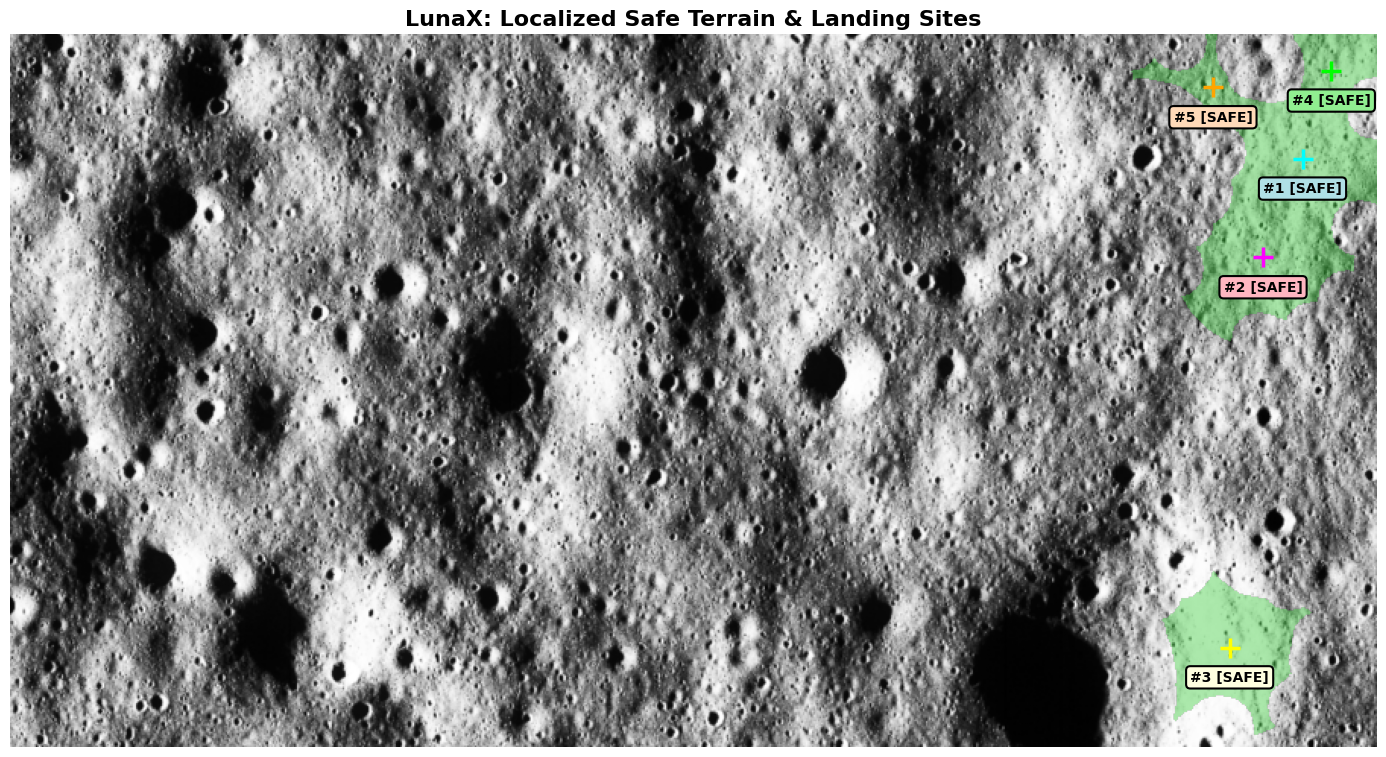

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# ---------- LUNAX FULL 5-FACTOR SUITABILITY ENGINE ----------
NUM_LANDING_SITES   = 5
LANDER_RADIUS_PX    = 4
MIN_SITE_SPACING_PX = 60
HIGHLIGHT_RADIUS    = 60    # <--- NEW: Local search radius for visualization

H, W = gray_u8.shape

# --- 1. Hazard Masks & Distance Transforms ---
inv_crater  = (~crater_mask).astype(np.uint8) * 255
inv_boulder = (~boulder_mask).astype(np.uint8) * 255
inv_steep   = (~steep_mask).astype(np.uint8) * 255

dist_to_crater  = cv2.distanceTransform(inv_crater, cv2.DIST_L2, 5)
dist_to_boulder = cv2.distanceTransform(inv_boulder, cv2.DIST_L2, 5)
dist_to_steep   = cv2.distanceTransform(inv_steep, cv2.DIST_L2, 5)

# Border constraint
border_mask = np.ones((H, W), dtype=np.uint8) * 255
border_mask[:LANDER_RADIUS_PX, :] = 0
border_mask[-LANDER_RADIUS_PX:, :] = 0
border_mask[:, :LANDER_RADIUS_PX] = 0
border_mask[:, -LANDER_RADIUS_PX:] = 0
dist_to_border = cv2.distanceTransform(border_mask, cv2.DIST_L2, 5)

# --- 2. Calculate Global Usable Area (Connected Components) ---
# We use a slightly relaxed threshold (< 0.1) to find continuous safe regions
visual_safe_zone = (total_risk < 0.1).astype(np.uint8) * 255
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(visual_safe_zone, connectivity=8)

usable_area_map = np.zeros((H, W), dtype=np.float32)
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    usable_area_map[labels == i] = area

max_usable_area = np.max(usable_area_map) if np.max(usable_area_map) > 0 else 1.0
usable_area_score = usable_area_map / max_usable_area

# --- 3. Calculate Gradient & Flatness ---
if 'grad_mag' not in globals():
    gray_float = gray_u8.astype(np.float32) / 255.0
    blur = cv2.GaussianBlur(gray_float, (0,0), sigmaX=2.5)
    gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5)
    gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5)
    grad_mag = np.sqrt(gx**2 + gy**2)

max_grad = np.percentile(grad_mag, 99)
flatness_score = 1.0 - np.clip(grad_mag / max_grad, 0, 1)

safe_zone = (total_risk == 0.0).astype(np.uint8) * 255
clearance_map = cv2.distanceTransform(safe_zone, cv2.DIST_L2, 5)
true_clearance_map = np.minimum(clearance_map, dist_to_border)
max_clearance = np.max(true_clearance_map) if np.max(true_clearance_map) > 0 else 1.0
clearance_score = true_clearance_map / max_clearance

# --- 4. Select Top Candidates ---
prelim_score = (0.4 * clearance_score) + (0.3 * flatness_score) + (0.3 * usable_area_score)
prelim_score[true_clearance_map == 0] = 0

landing_sites = []
temp_score = prelim_score.copy()
for _ in range(NUM_LANDING_SITES):
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(temp_score)
    if max_val <= 0: break
    landing_sites.append((max_loc, max_val))
    cv2.circle(temp_score, max_loc, MIN_SITE_SPACING_PX, 0, -1)

# --- 5. Calculate Full 5-Factor Metrics for Each Site ---
raw_table_data = []
marker_colors = ['#00FFFF', '#FF00FF', '#00FF00', '#FFFF00', '#FFA500', '#FF4500', '#1E90FF', '#FFD700', '#FF1493', '#7FFF00']
box_colors = ['#B0E0E6', '#FFB6C1', '#90EE90', '#FFFFE0', '#FFDAB9', '#FFC0CB', '#ADD8E6', '#FFFACD', '#FFB6C1', '#98FB98']

for idx, (loc, _) in enumerate(landing_sites):
    x, y = loc

    d_crater, d_boulder, d_steep, d_border = int(dist_to_crater[y, x]), int(dist_to_boulder[y, x]), int(dist_to_steep[y, x]), int(dist_to_border[y, x])
    clearance = int(true_clearance_map[y, x])

    f_flat = float(flatness_score[y, x])

    patch_size = 5
    y1, y2 = max(0, y-patch_size), min(H, y+patch_size+1)
    x1, x2 = max(0, x-patch_size), min(W, x+patch_size+1)
    local_grad_patch = grad_mag[y1:y2, x1:x2]
    local_roughness = float(np.std(local_grad_patch))
    max_roughness = np.percentile(grad_mag, 99) if np.percentile(grad_mag, 99) > 0 else 1.0
    f_smooth = 1.0 - (local_roughness / max_roughness)

    f_clearance = float(clearance_score[y, x])
    f_area = float(usable_area_score[y, x])
    usable_area_px = int(usable_area_map[y, x])

    R = LANDER_RADIUS_PX
    ry1, ry2 = max(0, y-R), min(H, y+R+1)
    rx1, rx2 = max(0, x-R), min(W, x+R+1)
    risk_patch = total_risk[ry1:ry2, rx1:rx2]

    cy, cx = R, R
    Y, X = np.ogrid[:risk_patch.shape[0], :risk_patch.shape[1]]
    dist_from_center = np.sqrt((X - cx)**2 + (Y - cy)**2)
    circle_mask = dist_from_center <= R

    if np.sum(circle_mask) > 0:
        hazardous_pixels = np.sum((risk_patch > 0.1) & circle_mask)
        total_circle_pixels = np.sum(circle_mask)
        hazard_frac = hazardous_pixels / total_circle_pixels
    else:
        hazard_frac = 1.0

    f_hazard = 1.0 - hazard_frac

    final_suitability = (0.30 * f_flat) + (0.25 * f_smooth) + (0.25 * f_clearance) + (0.10 * f_area) + (0.10 * f_hazard)

    safety_score = min(100, int((clearance / LANDER_RADIUS_PX) * 100))
    threats = {"Crater": d_crater, "Boulder": d_boulder, "Steep Slope": d_steep, "Border": d_border}
    primary_threat = min(threats, key=threats.get)
    status = "SAFE" if safety_score >= 100 and hazard_frac < 0.1 else "EMERGENCY"

    raw_table_data.append({
        "Rank": idx + 1,
        "Site_ID": f"LS_{idx+1:02d}",
        "Status": status,
        "Final_Suitability": round(final_suitability, 4),
        "Safety_Score": safety_score,
        "F_Flat": round(f_flat, 4),
        "F_Smooth": round(f_smooth, 4),
        "F_Clearance": round(f_clearance, 4),
        "F_Area": round(f_area, 4),
        "F_Hazard": round(f_hazard, 4),
        "Hazard_Fraction": round(hazard_frac, 4),
        "Usable_Area_Px": usable_area_px,
        "Clearance_Px": clearance,
        "Distance_Crater": d_crater,
        "Distance_Boulder": d_boulder,
        "Distance_Steep": d_steep,
        "Distance_Border": d_border,
        "Primary_Threat": primary_threat,
        "Coordinates_X": x,
        "Coordinates_Y": y,
        "orig_idx": idx
    })

raw_table_data.sort(key=lambda item: (item["Final_Suitability"], item["Safety_Score"]), reverse=True)
for rank, data in enumerate(raw_table_data):
    data["Rank"] = rank + 1

# --- 6. Console Output ---
print("="*100)
print("LUNAX 5-FACTOR SUITABILITY ENGINE - MISSION REPORT")
print("="*100)
for data in raw_table_data:
    print(f"Site #{data['Rank']} - {data['Site_ID']} [{data['Status']}]")
    print(f"  Final Suitability: {data['Final_Suitability']} | Safety: {data['Safety_Score']}/100")
    print(f"  Factors -> Flat: {data['F_Flat']} | Smooth: {data['F_Smooth']} | Clear: {data['F_Clearance']} | Area: {data['F_Area']} | Hazard: {data['F_Hazard']}")
    print(f"  Hazard Fraction: {data['Hazard_Fraction']} | Usable Area: {data['Usable_Area_Px']}px")
    print(f"  Primary Threat: {data['Primary_Threat']} | Coords: ({data['Coordinates_X']}, {data['Coordinates_Y']})")
    print("-" * 100)

# --- 7. CSV Export ---
df_columns = ["Rank", "Site_ID", "Status", "Final_Suitability", "Safety_Score",
              "F_Flat", "F_Smooth", "F_Clearance", "F_Area", "F_Hazard",
              "Hazard_Fraction", "Usable_Area_Px", "Clearance_Px",
              "Distance_Crater", "Distance_Boulder", "Distance_Steep", "Distance_Border",
              "Primary_Threat", "Coordinates_X", "Coordinates_Y"]
df_data = [{col: data[col] for col in df_columns} for data in raw_table_data]
df = pd.DataFrame(df_data)
csv_path = "lunax_landing_sites.csv"
df.to_csv(csv_path, index=False)
print(f"\nCSV file saved: {csv_path}")
print("="*100)

# --- 8. Visual Map: Localized Safe Zones (Fixed) ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(gray_u8, cmap='gray')
ax.set_title(f"LunaX: Localized Safe Terrain & Landing Sites", fontsize=16, fontweight='bold')
ax.axis('off')

# Create an RGBA overlay for the safe regions
overlay = np.zeros((H, W, 4), dtype=np.float32)

for data in raw_table_data:
    x, y = data["Coordinates_X"], data["Coordinates_Y"]

    # Find the connected component ID for this site
    comp_id = labels[y, x]

    # If it's part of a safe region (not background 0)
    if comp_id > 0:
        # 1. Get the global safe region mask
        region_mask = (labels == comp_id)

        # 2. Create a local circular mask (The "Local Search Radius" fix)
        # FIX: Changed dtype to np.uint8 so OpenCV can draw on it
        local_mask = np.zeros((H, W), dtype=np.uint8)
        cv2.circle(local_mask, (x, y), HIGHLIGHT_RADIUS, 255, -1)

        # 3. Intersect them: Only highlight safe pixels WITHIN the radius
        # (local_mask > 0) converts the uint8 circle back to boolean for the intersection
        local_safe_mask = region_mask & (local_mask > 0)

        # 4. Apply a unified Lime Green color with 40% opacity
        overlay[local_safe_mask] = [0.2, 0.8, 0.2, 0.4]

# Plot the unified safe region overlay
ax.imshow(overlay)

# Plot markers and labels on top
for data in raw_table_data:
    x, y = data["Coordinates_X"], data["Coordinates_Y"]
    orig_idx = data["orig_idx"]
    mc = marker_colors[orig_idx % len(marker_colors)]
    bc = box_colors[orig_idx % len(box_colors)]

    # Center marker
    ax.plot(x, y, marker='+', color=mc, markersize=15, markeredgewidth=2.5, zorder=5)

    # Label below
    text_y = y + 15
    label_text = f"#{data['Rank']} [{data['Status']}]"

    ax.text(x, text_y, label_text, color='black',
            fontsize=10, fontweight='bold', ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=bc, alpha=1.0, edgecolor='black', linewidth=1.5),
            zorder=6)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import heapq
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------- MODULE 3: RISK-AWARE A* PATHFINDING ----------

def heuristic(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def get_neighbors(node, H, W):
    x, y = node
    neighbors = []
    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]:
        nx, ny = x + dx, y + dy
        if 0 <= nx < W and 0 <= ny < H:
            neighbors.append((nx, ny))
    return neighbors

def astar_pathfinding(start, goal, risk_map, risk_weight=50.0):
    H, W = risk_map.shape
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:
        current_f, current = heapq.heappop(open_set)
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in get_neighbors(current, H, W):
            is_diagonal = (neighbor[0] != current[0] and neighbor[1] != current[1])
            move_cost = 1.414 if is_diagonal else 1.0
            risk = risk_map[neighbor[1], neighbor[0]]
            step_cost = move_cost + (risk * risk_weight)
            tentative_g = g_score[current] + step_cost

            if tentative_g < g_score.get(neighbor, float('inf')):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal)
                f_score[neighbor] = f
                heapq.heappush(open_set, (f, neighbor))
    return None

# ==========================================
# PHASE 1: LIVE-PREVIEW SLIDER SELECTION
# ==========================================
print("="*100)
print("LUNAX MODULE 3: RISK-AWARE ROUTE PLANNER")
print("="*100)

state = {
    'start_x': W // 4, 'start_y': H // 2,
    'goal_x': 3 * W // 4, 'goal_y': H // 2
}

preview_output = widgets.Output()
route_output = widgets.Output()

def update_preview(change=None):
    with preview_output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(gray_u8, cmap='gray')
        ax.set_title("Phase 1: Drag sliders to move Start (Green) and Goal (Red) pins", fontsize=14, fontweight='bold')
        ax.axis('off')

        ax.plot(state['start_x'], state['start_y'], 'o', color='lime', markersize=12, markeredgecolor='black')
        ax.text(state['start_x']+10, state['start_y']-10, f"Start ({state['start_x']}, {state['start_y']})",
                color='lime', fontweight='bold', fontsize=10)

        ax.plot(state['goal_x'], state['goal_y'], 'X', color='red', markersize=12, markeredgecolor='black')
        ax.text(state['goal_x']+10, state['goal_y']-10, f"Goal ({state['goal_x']}, {state['goal_y']})",
                color='red', fontweight='bold', fontsize=10)

        plt.tight_layout()
        plt.show()

sx = widgets.IntSlider(description='Start X:', min=0, max=W-1, value=state['start_x'], style={'description_width': 'initial'})
sy = widgets.IntSlider(description='Start Y:', min=0, max=H-1, value=state['start_y'], style={'description_width': 'initial'})
gx = widgets.IntSlider(description='Goal X:', min=0, max=W-1, value=state['goal_x'], style={'description_width': 'initial'})
gy = widgets.IntSlider(description='Goal Y:', min=0, max=H-1, value=state['goal_y'], style={'description_width': 'initial'})

def on_slider_change(change):
    state['start_x'] = sx.value
    state['start_y'] = sy.value
    state['goal_x'] = gx.value
    state['goal_y'] = gy.value
    update_preview()

sx.observe(on_slider_change, names='value')
sy.observe(on_slider_change, names='value')
gx.observe(on_slider_change, names='value')
gy.observe(on_slider_change, names='value')

update_preview()

# ==========================================
# PHASE 2: ROUTE GENERATION & CLEAN OUTPUT
# ==========================================
def on_generate_clicked(b):
    global routes_data  # <--- THIS IS THE FIX: Makes routes visible to other cells

    with route_output:
        clear_output()
        start = (state['start_x'], state['start_y'])
        goal = (state['goal_x'], state['goal_y'])

        print(f"\n🚀 Calculating routes from {start} to {goal}...")

        strategies = [
            {"name": "Distance Priority", "weight": 5.0, "color": "#FF4500", "style": "-."},
            {"name": "Balanced (Optimal)", "weight": 50.0, "color": "#00FF00", "style": "-"},
            {"name": "Maximum Safety", "weight": 500.0, "color": "#00FFFF", "style": "--"}
        ]

        routes_data = []
        for strat in strategies:
            path = astar_pathfinding(start, goal, total_risk, risk_weight=strat["weight"])
            if path is None:
                print(f"❌ {strat['name']}: No valid path found")
                continue

            path_risks = [total_risk[y, x] for x, y in path]
            avg_risk = np.mean(path_risks)
            distance_px = sum(1.414 if abs(path[i][0]-path[i-1][0])==1 and abs(path[i][1]-path[i-1][1])==1 else 1.0 for i in range(1, len(path)))
            safety_score = max(0, 100 - (avg_risk * 100))

            routes_data.append({
                "Strategy": strat["name"],
                "Distance (px)": round(distance_px, 1),
                "Avg Risk": round(avg_risk, 4),
                "Safety Score": round(safety_score, 1),
                "Path": path,
                "Color": strat["color"],
                "Style": strat["style"]
            })
            print(f"✅ {strat['name']}: Dist={distance_px:.1f}px | Avg Risk={avg_risk:.3f} | Safety={safety_score:.1f}/100")

        if routes_data:
            df_routes = pd.DataFrame([{
                "Strategy": r["Strategy"],
                "Distance_Px": r["Distance (px)"],
                "Avg_Risk": r["Avg Risk"],
                "Safety_Score": r["Safety Score"]
            } for r in routes_data])
            df_routes.to_csv("lunax_routes.csv", index=False)
            print("\n📊 Routes saved to: lunax_routes.csv")

            fig2, ax2 = plt.subplots(figsize=(14, 10))
            ax2.imshow(gray_u8, cmap='gray', alpha=0.9)
            ax2.set_title("Phase 2: LunaX Risk-Aware Route Execution", fontsize=16, fontweight='bold')
            ax2.axis('off')

            for r in routes_data:
                path = r["Path"]
                xs, ys = zip(*path)
                ax2.plot(xs, ys, color=r["Color"], linestyle=r["Style"], linewidth=3,
                       label=f"{r['Strategy']} (Safety: {r['Safety Score']})")

            ax2.plot(start[0], start[1], 'o', color='lime', markersize=15, markeredgecolor='black', label='Start', zorder=10)
            ax2.plot(goal[0], goal[1], 'X', color='red', markersize=15, markeredgecolor='black', label='Goal', zorder=10)

            ax2.legend(loc='upper right', fontsize=11, framealpha=0.9, edgecolor='gray')
            plt.tight_layout()
            plt.show()
        else:
            print("\n⚠️ Could not find any valid paths. Try selecting points in safer (greener) areas.")

plan_btn = widgets.Button(description="🚀 GENERATE ROUTES", button_style='success',
                         layout=widgets.Layout(width='250px', height='40px'))
plan_btn.on_click(on_generate_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Phase 1: Select Waypoints</h3>"),
    preview_output,
    widgets.HTML("<br><b>Start Coordinates:</b>"),
    widgets.HBox([sx, sy]),
    widgets.HTML("<br><b>Goal Coordinates:</b>"),
    widgets.HBox([gx, gy]),
    widgets.HTML("<br>"),
    plan_btn,
    widgets.HTML("<br><h3>Phase 2: Route Telemetry & Clean Map</h3>"),
    route_output
]))



LUNAX MODULE 3: RISK-AWARE ROUTE PLANNER


LUNAX MODULE: GROUNDED 3D TERRAIN & ROUTES


In [ ]:
import numpy as np
import cv2
import plotly.graph_objects as go

print("="*100)
print("LUNAX MODULE: GROUNDED 3D TERRAIN & ROUTES")
print("="*100)

# 1. Create a REALISTIC Heightmap
base_terrain = cv2.GaussianBlur(gray_u8, (151, 151), 0).astype(float)
Z_base = (base_terrain / 255.0) * 3.0
Z_craters = total_risk * 15.0
terrain_z = Z_base - Z_craters

# Downsample for Plotly performance
step = 4
X, Y = np.meshgrid(np.arange(0, W, step), np.arange(0, H, step))
Z = terrain_z[::step, ::step]

# Flip Y-axis to match image coordinates
Y_3d = H - Y
texture = gray_u8[::step, ::step]

# 2. Initialize Plotly Figure
fig = go.Figure()

# --- PLOT 1: 3D TERRAIN SURFACE ---
fig.add_trace(go.Surface(
    x=X, y=Y_3d, z=Z,
    surfacecolor=texture,
    colorscale='Gray',
    showscale=False,
    name="Lunar Terrain"
))

# --- PLOT 2: 3D ROUTE TRAJECTORIES (GROUNDED) ---
if 'routes_data' in globals() and len(globals()['routes_data']) > 0:
    routes = globals()['routes_data']

    for r in routes:
        path = r["Path"]
        path_x = [p[0] for p in path]
        path_y = [H - p[1] for p in path]

        # FIX: Removed the +2.0 offset. Routes now sit exactly on the surface Z.
        path_z = [terrain_z[p[1], p[0]] for p in path]

        fig.add_trace(go.Scatter3d(
            x=path_x, y=path_y, z=path_z,
            mode='lines',
            line=dict(color=r["Color"], width=6),
            name=f"{r['Strategy']} (Safety: {r['Safety Score']})"
        ))

    # Add Start and Goal markers
    start = (state['start_x'], state['start_y'])
    goal = (state['goal_x'], state['goal_y'])

    start_y_3d = H - start[1]
    goal_y_3d = H - goal[1]

    # FIX: Grounded pins
    start_z = terrain_z[start[1], start[0]]
    goal_z = terrain_z[goal[1], goal[0]]

    fig.add_trace(go.Scatter3d(
        x=[start[0]], y=[start_y_3d], z=[start_z],
        mode='markers',
        marker=dict(size=10, color='lime', symbol='circle', line=dict(color='black', width=2)),
        name="Start"
    ))

    fig.add_trace(go.Scatter3d(
        x=[goal[0]], y=[goal_y_3d], z=[goal_z],
        mode='markers',
        marker=dict(size=10, color='red', symbol='x', line=dict(color='black', width=2)),
        name="Goal"
    ))

# 3. Layout and Aesthetics
fig.update_layout(
    title=dict(
        text="LunaX Interactive 3D Terrain Navigation (Grounded Routes)",
        font=dict(size=20, color='white')
    ),
    scene=dict(
        xaxis_title='X Coordinate (pixels)',
        yaxis_title='Y Coordinate (pixels)',
        zaxis_title='Elevation (Units)',
        aspectmode='data',
        camera=dict(
            eye=dict(x=1.2, y=1.2, z=0.6)
        ),
        bgcolor='black'
    ),
    template='plotly_dark',
    width=1400,
    height=800,
    legend=dict(
        x=0.01, y=0.99,
        font=dict(size=12, color='white'),
        bgcolor='rgba(0,0,0,0.5)'
    )
)

fig.show()

LUNAX MODULE: GROUNDED 3D TERRAIN & ROUTES
